

# 911 Calls Data Analysis Capstone Project

© Darey.io

For this data analysis project we will be analyzing some 911 call data from [Kaggle](https://www.kaggle.com/mchirico/montcoalert). The data contains the following fields:

* lat : String variable, Latitude
* lng: String variable, Longitude
* desc: String variable, Description of the Emergency Call
* zip: String variable, Zipcode
* title: String variable, Title
* timeStamp: String variable, YYYY-MM-DD HH:MM:SS
* twp: String variable, Township
* addr: String variable, Address
* e: String variable, Dummy variable (always 1)

Just go along with this notebook and try to complete the instructions or answer the questions in bold using your Python and Data Analytics skills!

### Section 1: Data and Setup

____
**Import numpy and pandas**

In [2]:
#importing numpy and pandas libraries

import numpy as np
import pandas as pd 

**Import visualization libraries and set %matplotlib inline.**

In [4]:
#Importing libraries for data visualization

import matplotlib.pyplot as plt  # For basic charts like bar, line, pie
import seaborn as sns # For prettier, more advanced charts
%matplotlib inline

# Set %matplotlib inline
# This is a magic command (just for Jupyter notebooks) that tells Python:
# “Please show the chart right below the code cell instead of opening it in a separate window.”
# It only works in notebooks and makes it easier to see results immediately.

**Read in the csv file as a dataframe called df**

In [5]:
#Ask pandas to read 911 csv dataset and load as df

df = pd.read_csv ('911.csv')

**Check the info() of the df**

In [8]:
#checking information about dataset

df.info() # View summary info (columns, data types, etc.)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663522 entries, 0 to 663521
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   lat        663522 non-null  float64
 1   lng        663522 non-null  float64
 2   desc       663522 non-null  object 
 3   zip        583323 non-null  float64
 4   title      663522 non-null  object 
 5   timeStamp  663522 non-null  object 
 6   twp        663229 non-null  object 
 7   addr       663522 non-null  object 
 8   e          663522 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 45.6+ MB


**Check the head of df**

In [61]:
#view first five rows of the dataset to confirm if it loads well

df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Month,Day of Week,Date
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,17,12,Thu,2015-12-10
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,17,12,Thu,2015-12-10
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1,Fire,14,12,Thu,2015-12-10
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS,16,12,Thu,2015-12-10
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1,EMS,16,12,Thu,2015-12-10


### Section 2: Basic Questions

**What are the top 5 zipcodes for 911 calls?**

In [10]:
#Displaying the top 5 zip codes with the most calls

df['zip'].value_counts().head(5)

# Groups the calls by the zip column.
# Counts how many calls came from each zip code.

zip
19401.0    45606
19464.0    43910
19403.0    34888
19446.0    32270
19406.0    22464
Name: count, dtype: int64

**What are the top 5 townships (twp) for 911 calls?**

In [62]:
# Displaying the top 5 townships with the most calls

df['twp'].value_counts().head(5)

# Groups the calls by the township (twp) column.
# Counts how many calls came from each township.

twp
LOWER MERION    55490
ABINGTON        39947
NORRISTOWN      37633
UPPER MERION    36010
CHELTENHAM      30574
Name: count, dtype: int64

**Take a look at the 'title' column, how many unique title codes are there?**

In [63]:
#Viewing the total number of unique title codes in the dataframe title column

df['title'].nunique()

# df['title'] → Looks at the column named 'title', which contains the reason/type of each 911 call (like EMS, Fire, etc.).
# .nunique() → Stands for "number of unique" values.
# It tells us how many different types of titles exist in the dataset.

148

### Section 3: Creating new features

**In the titles column there are "Reasons/Departments" specified before the title code. These are EMS, Fire, and Traffic. Use .apply() with a custom lambda expression to create a new column called "Reason" that contains this string value.**

**For example, if the title column value is EMS: BACK PAINS/INJURY, the Reason column value would be EMS.**

In [64]:
#Creating new feature: a new column 'Reason'

df['Reason'] = df['title'].apply(lambda x: x.split(':')[0])

# df['title']	Selects the column that contains values like "EMS: BACK PAINS/INJURY"
# .apply(...)	Runs a function on each value in that column
# lambda x: ...	A short, anonymous function where x is each individual title
# x.split(':')	Splits the string into parts wherever : appears. For example: 'EMS: BACK PAINS/INJURY' becomes ['EMS', ' BACK PAINS/INJURY']
# [0]	Grabs the first part (before the colon), like 'EMS'
# df['Reason'] = ...	Stores this new value in a new column called 'Reason'

**What is the most common Reason for a 911 call based off of this new column?**

In [65]:
#Checking most common reason for 911 calls

df['Reason'].value_counts().idxmax()

# df['Reason']: looking inside the 'Reason' column of the DataFrame (df).
# This column contains values like: EMS, Fire, Traffic  
# .value_counts(): This part counts how many times each unique value appears.
# It gives something like:
# EMS        50000  
# Traffic    35000  
# Fire       15000  
# .idxmax(): This means: "Get the index (the label) of the maximum value."
# In this case, the "index" is the actual reason (e.g. 'EMS'), and the maximum is the one with the highest count. 
# So .idxmax() pulls out just: 'EMS'

'EMS'

**Now use seaborn to create a countplot of 911 calls by Reason.**

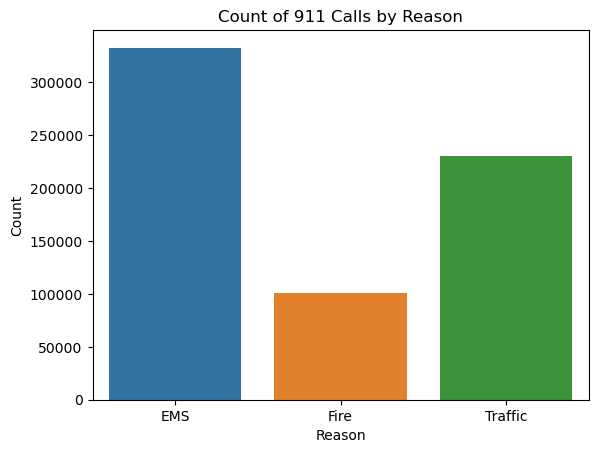

In [66]:
#Using seaborn to create a countplot of 911 calls by reason

# Create a countplot with both x and hue set to 'Reason'
sns.countplot(x='Reason', hue='Reason', data=df, palette={'EMS': '#1f77b4', 'Fire': '#ff7f0e', 'Traffic': '#2ca02c'})

# Remove legend (since x == hue, the legend just duplicates labels)
plt.legend([],[], frameon=False)

# Add title and labels
plt.title('Count of 911 Calls by Reason')
plt.xlabel('Reason')
plt.ylabel('Count')

# Show the plot
plt.show()

# sns.countplot(...) This is a Seaborn function that creates a bar chart of counts.
# x='Reason': Put the "Reason" column on the X-axis.
#hue='Reason' is added to match the palette usage, which is required by newer versions of Seaborn.
# data=df: Use your 911 calls DataFrame.
# palette={'EMS': '#1f77b4', 'Fire': '#ff7f0e', 'Traffic': '#2ca02c'}: Choose a nice color scheme.
# We remove the legend using plt.legend([],[], frameon=False) because when x == hue, the legend becomes redundant.
# plt.title(...), plt.xlabel(...), plt.ylabel(...) These are from Matplotlib, used to add labels and title to the chart.
# plt.show() This displays the chart.



___
**Now let us begin to focus on time information. What is the data type of the objects in the timeStamp column?**

In [21]:
# Checking the data type of the timeStamp column

print(type(df['timeStamp'][0]))

<class 'str'>


**You should have seen that these timestamps are still strings. Use [pd.to_datetime](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.to_datetime.html) to convert the column from strings to DateTime objects.**

In [22]:
# Convert the timeStamp column to datetime objects

df['timeStamp'] = pd.to_datetime(df['timeStamp'])

# pd.to_datetime(...) is a Pandas function that takes a string like '2015-12-10 17:40:00' 
#and turns it into a real timestamp that Python can understand and work with.
# After this conversion, we can extract things like: The hour of the call, The day of the week, The month etc.

**You can now grab specific attributes from a Datetime object by calling them. For example:**

    time = df['timeStamp'].iloc[0]
    time.hour

**You can use Jupyter's tab method to explore the various attributes you can call. Now that the timestamp column are actually DateTime objects, use .apply() to create 3 new columns called Hour, Month, and Day of Week. You will create these columns based off of the timeStamp column.**

In [67]:
# Create 'Hour', 'Month', and 'Day of Week' columns using .apply()

#creating 'Hour' using lambda fucnction
df['Hour'] = df['timeStamp'].apply(lambda time: time.hour)

#creating 'Month' using lambda fucnction
df['Month'] = df['timeStamp'].apply(lambda time: time.month)

#creating 'Day of Week' using lambda fucnction
df['Day of Week'] = df['timeStamp'].apply(lambda time: time.dayofweek)

# df['timeStamp']: This is the datetime column (already converted).
# .apply(lambda time: time.hour): For each timestamp, extract the hour.
# dayofweek: Returns a number where: 0 = Monday, 1 = Tuesday, ..., 6 = Sunday.

**Notice how the Day of Week is an integer 0-6. Use the .map() with this dictionary to map the actual string names to the day of the week:**

    dmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

In [68]:
# Create a dictionary to map day numbers to names
dmap = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

# Apply the mapping to the 'Day of Week' column
df['Day of Week'] = df['Day of Week'].map(dmap)

# View the result
df[['timeStamp', 'Day of Week']].head()

# dmap: A simple dictionary where each number is mapped to a short form of a weekday.
# .map(dmap): Replaces the numbers in the Day of Week column with the corresponding string names.

,timeStamp,Day of Week
0,2015-12-10 17:10:52,Thu
1,2015-12-10 17:29:21,Thu
2,2015-12-10 14:39:21,Thu
3,2015-12-10 16:47:36,Thu
4,2015-12-10 16:56:52,Thu


**Now use seaborn to create a countplot of the Day of Week column with the hue based off of the Reason column.**

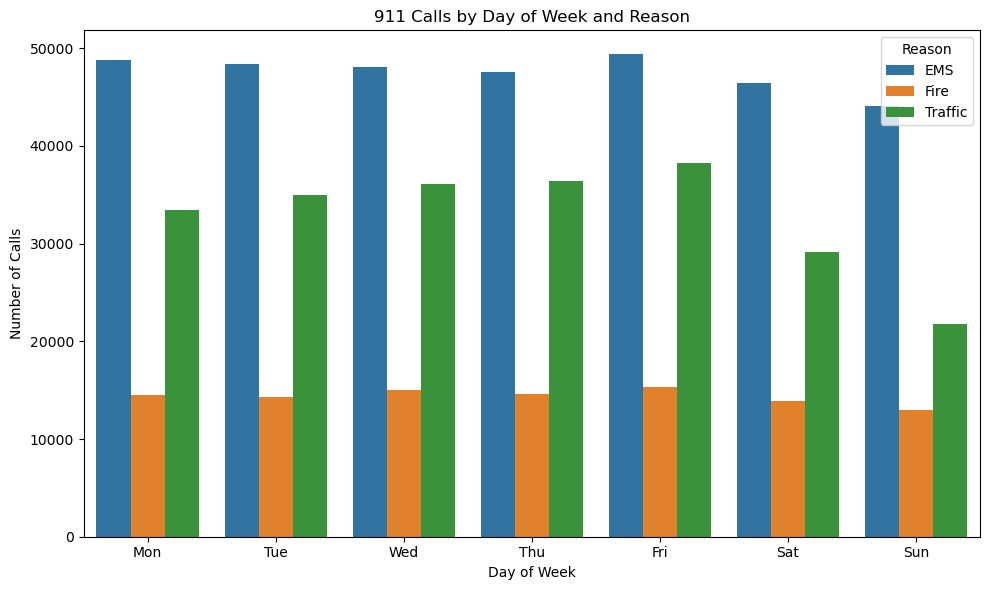

In [69]:
# Define the correct order for the days
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Plot the countplot with correct order
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Day of Week', hue='Reason', order=day_order)

# Customize
plt.title('911 Calls by Day of Week and Reason')
plt.xlabel('Day of Week')
plt.ylabel('Number of Calls')
plt.legend(title='Reason')
plt.tight_layout()
plt.show()

# order=day_order tells Seaborn to respect custom ordering instead of sorting alphabetically.
# x='Day of Week': sets the x-axis to show weekdays (e.g. Mon, Tue…).
# hue='Reason': color-codes the bars by reason (EMS, Fire, Traffic).
# plt.figure(figsize=(10, 6)): makes the plot wider for better readability.
# plt.tight_layout(): reduces extra spacing.

**Now do the same for Month:**

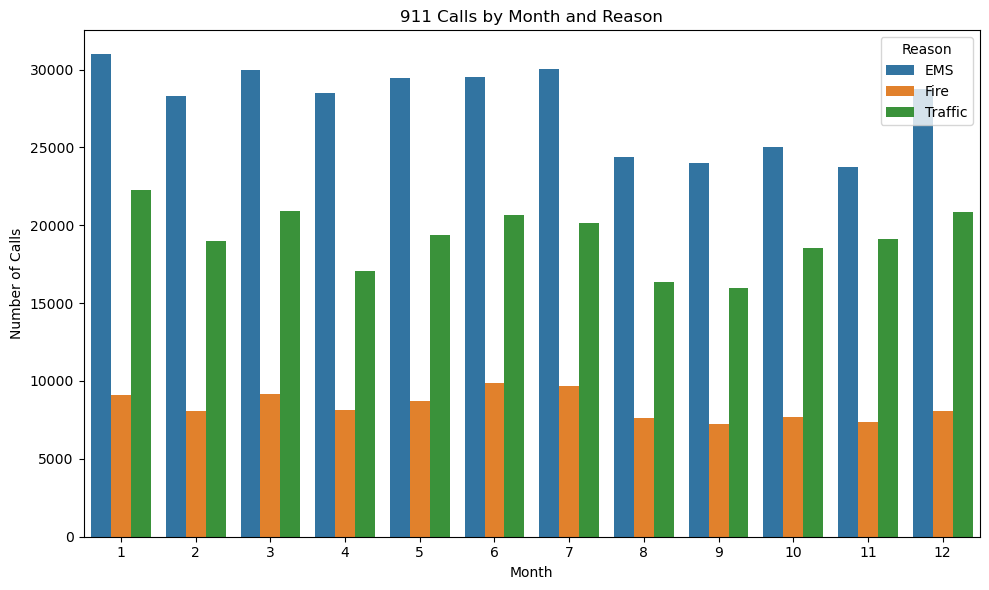

In [70]:
# Define the correct order for months (1 through 12)
month_order = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# Plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Month', hue='Reason', order=month_order)

# Customize
plt.title('911 Calls by Month and Reason')
plt.xlabel('Month')
plt.ylabel('Number of Calls')
plt.legend(title='Reason')
plt.tight_layout()
plt.show()


**Did you notice something strange about the Plot?**

_____

**You should have noticed it was missing some Months, let's see if we can maybe fill in this information by plotting the information in another way, possibly a simple line plot that fills in the missing months, in order to do this, we'll need to do some work with pandas...**

**Now create a groupby object called byMonth, where you group the DataFrame by the month column and use the count() method for aggregation. Use the head() method on this returned DataFrame.**

In [71]:
# Group the dataframe by the 'Month' column
byMonth = df.groupby('Month').count()

# Preview the result
byMonth.head()

# This byMonth DataFrame now has months as index and the count of each column for that month.

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Day of Week,Date
Month,,,,,,,,,,,,,
1,62336,62336,62336,55294,62336,62336,62312,62336,62336,62336,62336,62336,62336
2,55427,55427,55427,48922,55427,55427,55405,55427,55427,55427,55427,55427,55427
3,60027,60027,60027,53252,60027,60027,60001,60027,60027,60027,60027,60027,60027
4,53671,53671,53671,47349,53671,53671,53655,53671,53671,53671,53671,53671,53671
5,57509,57509,57509,50354,57509,57509,57474,57509,57509,57509,57509,57509,57509


**Now create a simple plot off of the dataframe indicating the count of calls per month.**

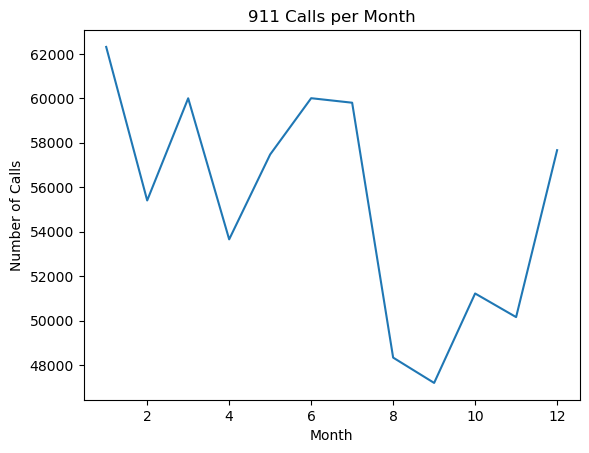

In [72]:
# Plot the number of calls per month using one of the columns (e.g., 'twp')
byMonth['twp'].plot()

# Customize the plot
plt.title('911 Calls per Month')
plt.xlabel('Month')
plt.ylabel('Number of Calls')
plt.show()

# byMonth['twp']: use the 'twp' column (or any other non-null column) as a representative to count calls.
# .plot(): Creates a line chart.
# plt.title(), plt.xlabel(), plt.ylabel(): Label the chart for clarity.
# plt.show(): Displays the plot.

**Now see if you can use seaborn's lmplot() to create a linear fit on the number of calls per month. Keep in mind you may need to reset the index to a column.**

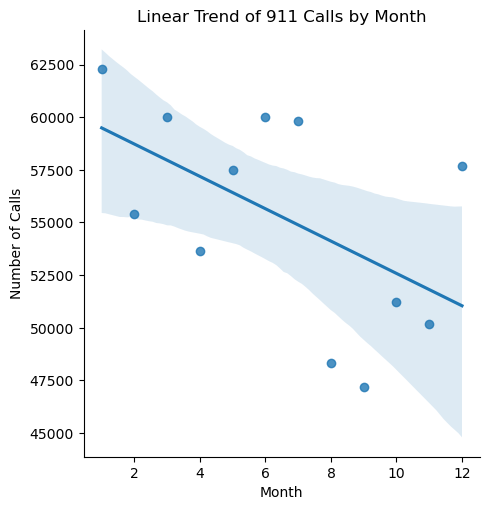

In [73]:
# Group by month and count the number of calls
byMonth = df.groupby('Month').count()

# Reset the index so 'Month' becomes a column (lmplot requires column data, not index)
byMonth = byMonth.reset_index()

# Create a linear fit plot
sns.lmplot(x='Month', y='twp', data=byMonth)

# Customize the plot
plt.title('Linear Trend of 911 Calls by Month')
plt.xlabel('Month')
plt.ylabel('Number of Calls')
plt.show()

# groupby('Month').count() → Groups the data by month and counts entries.
# reset_index() → Converts the index (Month) into a regular column so Seaborn can use it.
# sns.lmplot() → Draws a scatterplot and adds a linear regression line.
# x='Month': Independent variable on the x-axis.
# y='twp':  just picking one column to count (any non-null column would work here).
# plt.title() etc. → Labels for clarity.

**Create a new column called 'Date' that contains the date from the timeStamp column. You'll need to use apply along with the .date() method.**

In [74]:
# Create a new 'Date' column from the 'timeStamp' column
df['Date'] = df['timeStamp'].apply(lambda time: time.date())

#view top 5 rows
df['Date'].head() 

# df['timeStamp']: This column contains the full datetime (like 2015-12-10 17:40:00).
# .apply(lambda time: time.date()): Goes through each timestamp and extracts just the date part (e.g., 2015-12-10).
# df['Date']: This is the new column with the clean date (no time attached).

0    2015-12-10
1    2015-12-10
2    2015-12-10
3    2015-12-10
4    2015-12-10
Name: Date, dtype: object

**Now groupby this Date column with the count() aggregate and create a plot of counts of 911 calls.**

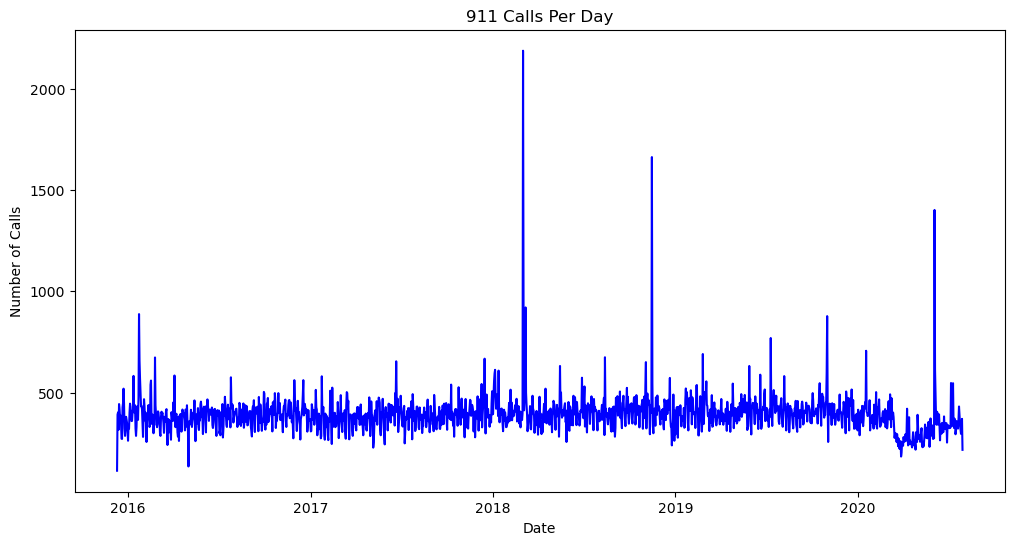

In [75]:
# Group by 'Date' and count how many calls happened on each date
calls_by_date = df.groupby('Date').count()

# Plot the number of calls per date
calls_by_date['twp'].plot(figsize=(12,6), color='blue')

# Add title and labels
plt.title('911 Calls Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Calls')
plt.show()

# df.groupby('Date').count() groups the dataset by each unique date and performs a count on all columns.
# choose one column (like 'twp') to plot — any non-null column will do since all are counted equally.
# plot() generates the line chart.
# figsize=(12,6) makes the chart bigger.
# color='blue' gives it a distinct color

**Now recreate this plot but create 3 separate plots with each plot representing a Reason for the 911 call**

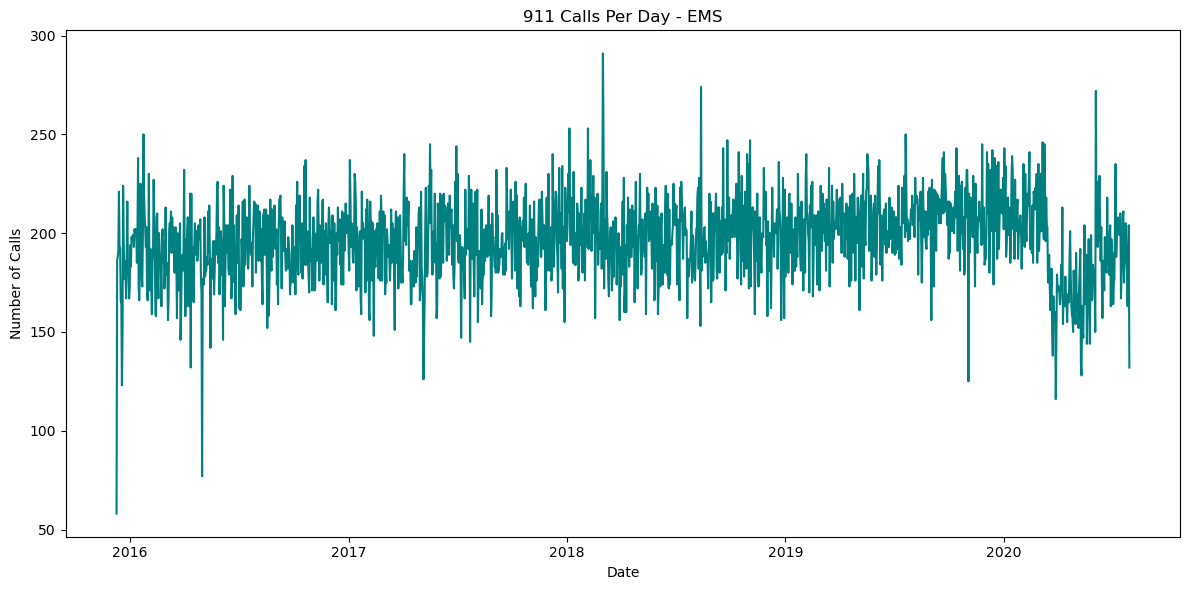

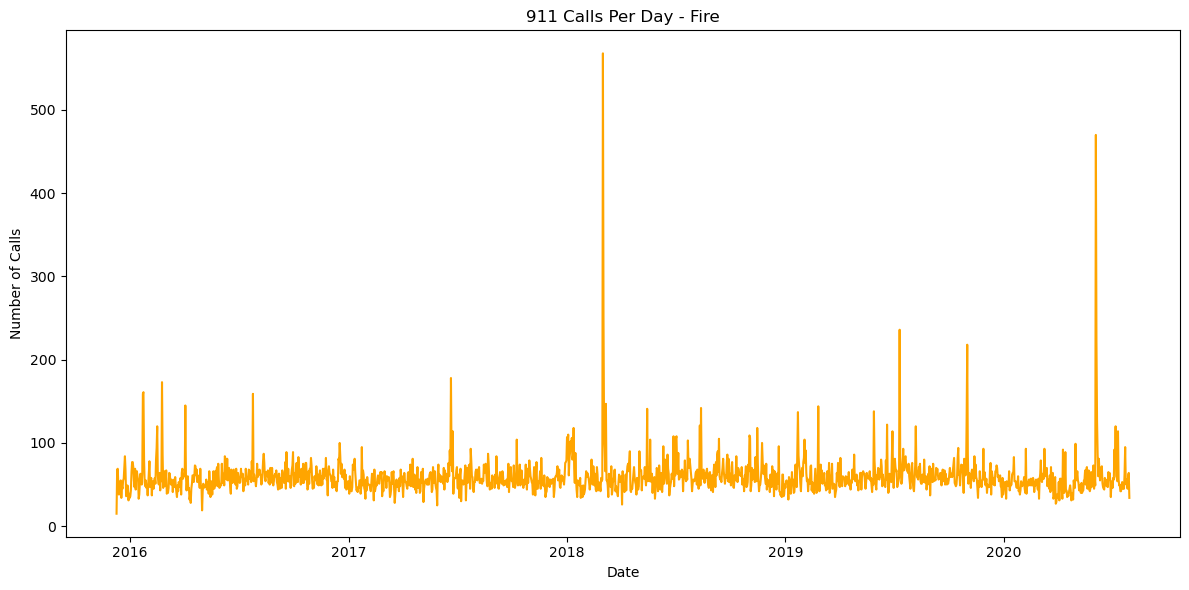

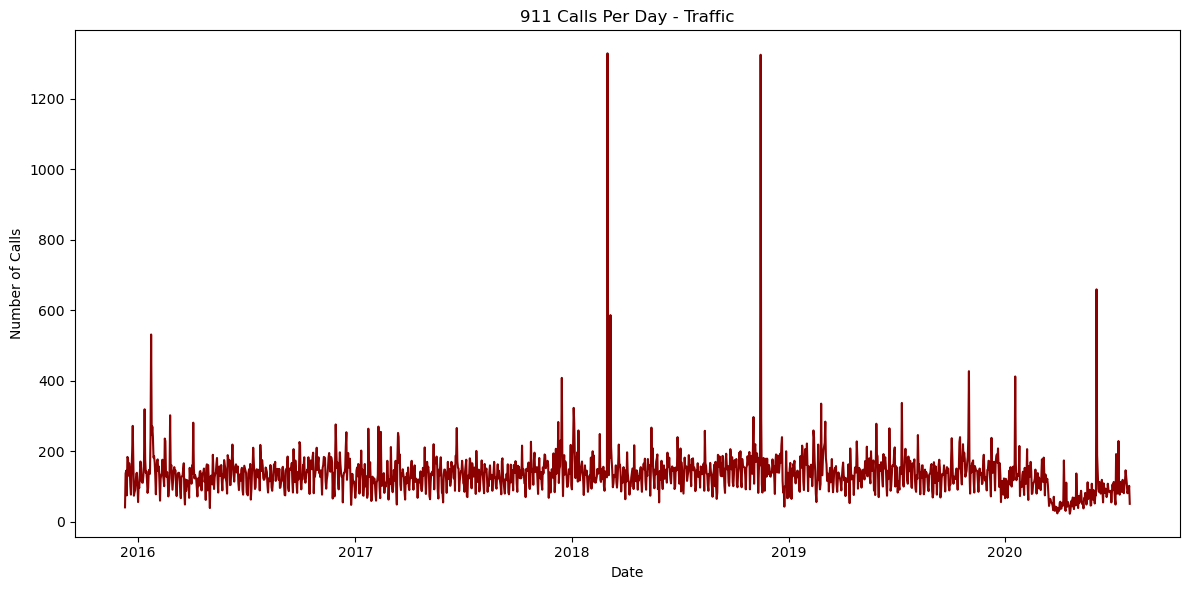

In [76]:
# Plot 911 calls per day for each Reason
for reason in df['Reason'].unique():
    df_reason = df[df['Reason'] == reason]
    calls_by_date = df_reason.groupby('Date').count()
    
    # Plot
    plt.figure(figsize=(12, 6))
    calls_by_date['twp'].plot(color='teal' if reason == 'EMS' else 'orange' if reason == 'Fire' else 'darkred')

    #customize title, layout and labels
    plt.title(f'911 Calls Per Day - {reason}')
    plt.xlabel('Date')
    plt.ylabel('Number of Calls')
    plt.tight_layout()

    #show
    plt.show()

# The for loop runs for each unique reason: 'EMS', 'Fire', and 'Traffic'.
# filtered the dataset (df_reason) for that reason.
# Then group by date and plot the call count for each.
# used the 'twp' column to count rows — it works as a representative column.
# Distinct colors are used per reason.

____
**Now let's move on to creating  heatmaps with seaborn and our data. We'll first need to restructure the dataframe so that the columns become the Hours and the Index becomes the Day of the Week. There are lots of ways to do this, but I would recommend trying to combine groupby with an [unstack](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.unstack.html) method.**

In [77]:
# Create a new DataFrame by grouping by Day of Week and Hour
day_hour = df.groupby(by=['Day of Week', 'Hour']).count()['twp'].unstack()

# Display the first few rows (optional)
day_hour.head()

# df.groupby(['Day of Week', 'Hour']) groups the data by day and hour.
# .count()['twp'] counts how many calls occurred (we use 'twp' just to count any column).
# .unstack() moves the Hour from index to columns, so it becomes a matrix:
# Rows = Days (Mon, Tue, ...)
# Columns = Hours (0–23)
# Values = Number of 911 calls

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Day of Week,,,,,,,,,,,,,,,,,,,,,
Fri,1981,1632,1449,1296,1338,1638,2663,4138,5017,5288,...,6392,7038,7064,7112,5667,5055,4373,3912,3421,2828
Mon,1893,1567,1366,1271,1336,1843,2675,4428,5502,5722,...,5713,6289,6341,6407,5440,4488,3823,3252,2654,2069
Sat,2442,2058,1879,1588,1449,1579,1879,2488,3457,4312,...,5420,5181,5210,5211,4979,4748,4125,3893,3224,2961
Sun,2423,2132,1938,1614,1468,1487,1725,2404,3001,3728,...,4744,4475,4559,4505,4402,4133,3747,3158,2627,2321
Thu,1731,1407,1424,1234,1292,1774,2814,4431,5296,5411,...,6078,6493,6374,6933,5510,4701,4043,3490,2844,2351


**Now create a HeatMap using this new DataFrame.**

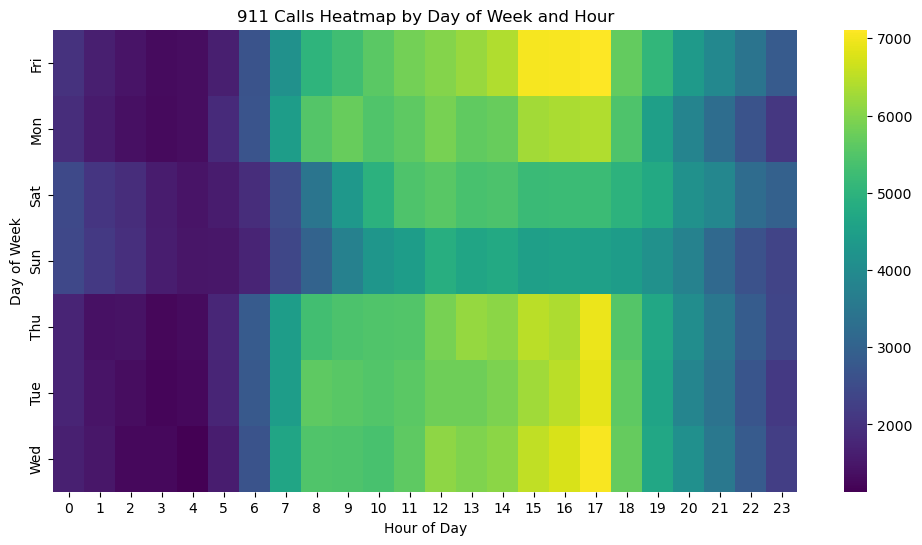

In [79]:
#plot 911 call heatmap by day of week and hour using the above dataframe

#plot
plt.figure(figsize=(12, 6))
sns.heatmap(day_hour, cmap='viridis')

#customize labels and title
plt.title('911 Calls Heatmap by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

#show chart
plt.show()

# Plt.figure(figsize=(12, 6)): This creates a blank figure (like an empty canvas) where the heatmap will be drawn.
# figsize=(12, 6) sets the width to 12 units and height to 6 units, making the chart big enough to read.
# sns.heatmap(day_hour, cmap='viridis') draws the heatmap using the Seaborn library.
# day_hour is the data (that matrix of counts grouped by day and hour).
# cmap='viridis' tells Seaborn what color scheme to use.
# 'viridis' is a popular color map that goes from dark blue → green → yellow.
# Darker = lower value (fewer calls), Brighter = higher value (more calls)

**Now create a clustermap using this DataFrame.**

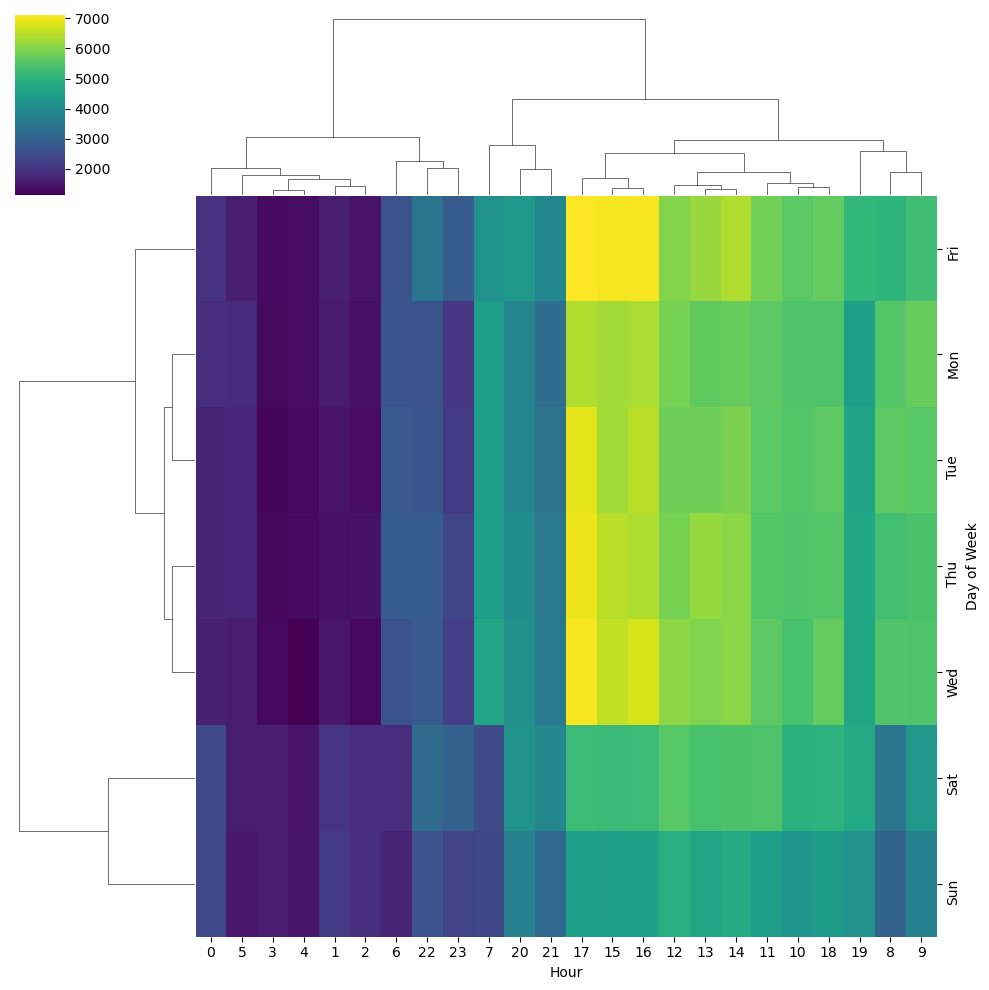

In [81]:
#plot
sns.clustermap(day_hour, cmap='viridis')

#show
plt.show()

# Tells matplotlib explicitly to render the last plot, including seaborn plots like clustermap.
# Works in both interactive and non-interactive environments.


**Now repeat these same plots and operations, for a DataFrame that shows the Month as the column.**

In [82]:
# Create a Day vs Month matrix
day_month = df.groupby(by=['Day of Week', 'Month']).count()['Reason'].unstack()

#view top 5 rows
day_month.head()

Month,1,2,3,4,5,6,7,8,9,10,11,12
Day of Week,,,,,,,,,,,,
Fri,9309,8255,10941,7997,8904,9207,8681,7336,7694,6934,8379,9305
Mon,8896,8747,8060,8410,7881,8511,9499,6854,6598,8075,6722,8492
Sat,8475,7593,8050,7514,7223,8198,7748,6111,6566,6609,6773,8592
Sun,7478,6452,6766,6865,6694,6837,7859,5275,5956,6316,5196,7165
Thu,9055,7997,8849,7722,8740,9489,8378,7508,6954,7482,8358,8151


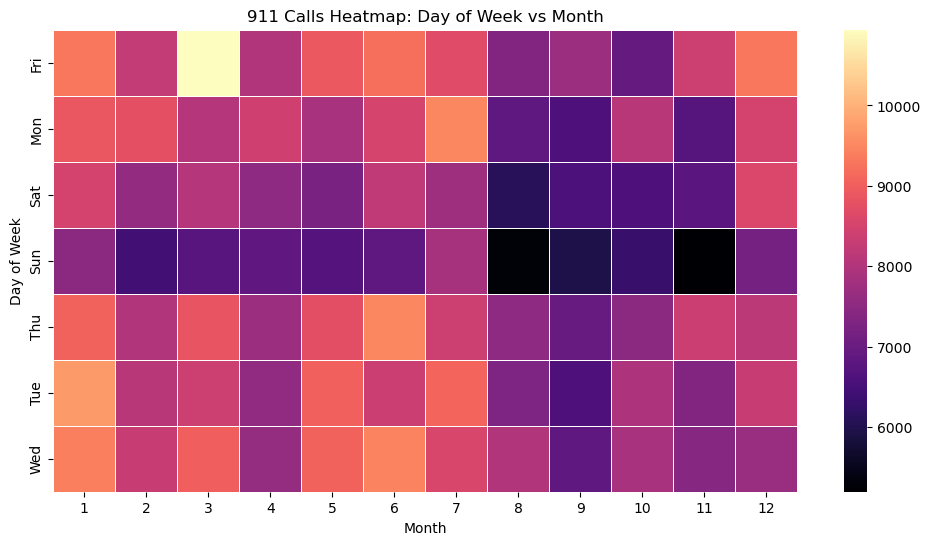

In [84]:
# Heatmap for Day of Week vs Month

#plot
plt.figure(figsize=(12,6))
sns.heatmap(day_month, cmap='magma', linewidths=0.5)

#customize title and labels
plt.title("911 Calls Heatmap: Day of Week vs Month")
plt.xlabel('Month')
plt.ylabel('Day of Week')

#show
plt.show()

# cmap='coolwarm': sets the color theme.
# linewidths=0.5: adds gridlines to make cells easier to see.

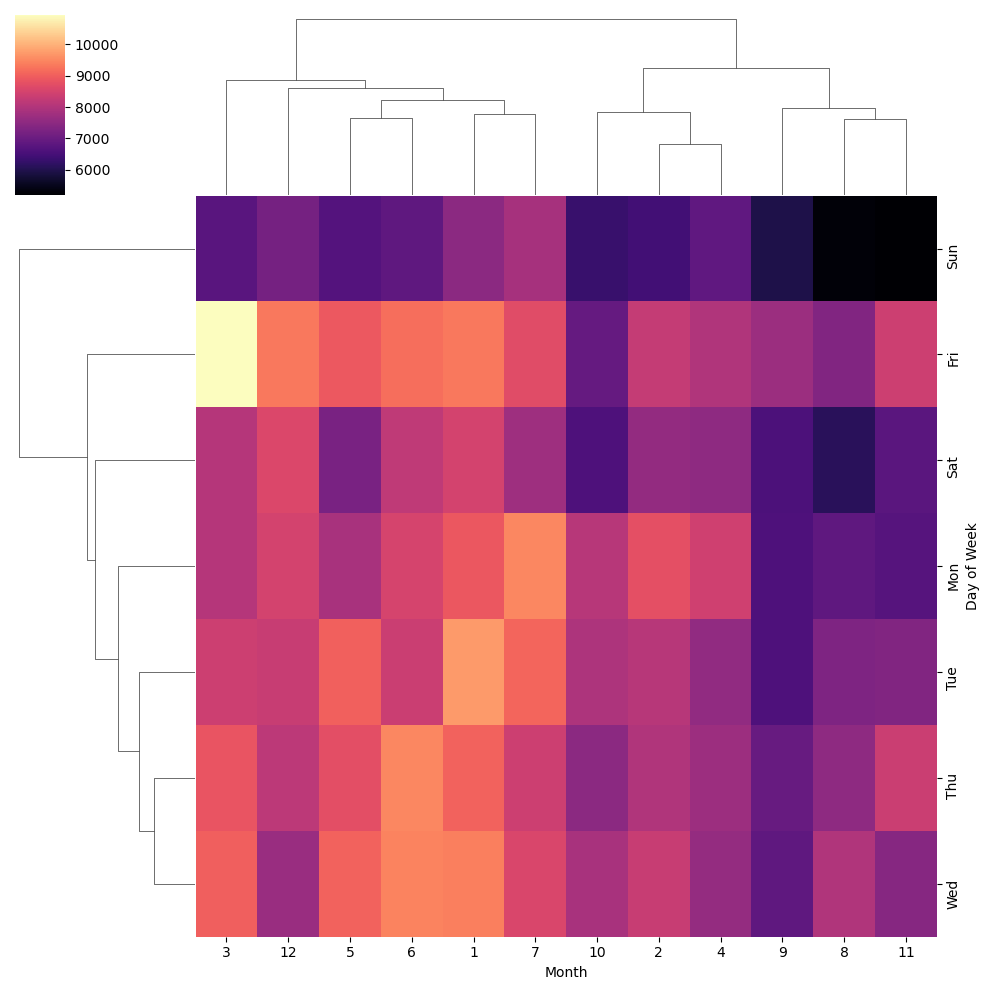

In [85]:
# Clustermap for Day of Week vs Month

#plot
sns.clustermap(day_month, cmap='magma')

#show
plt.show()

# Automatically clusters similar days and months based on call patterns.
# Gives insight into which days and months have similar activity.

In [88]:
# # **Summary of Findings**
# In this project, a real-world dataset of 911 emergency calls was analyzed to uncover trends and patterns 
# based on time, location, and reason for the calls. 

# Below are the key insights from the analysis:

# 1. Major Reasons for 911 Calls:
# EMS (Emergency Medical Services) was the most common reason for 911 calls.
# Fire and Traffic were also significant, but less frequent than EMS.

# 2. Day and Time Trends:
# The highest volume of 911 calls occurred on Fridays, followed by Mondays and Tuesdays.
# Most calls were made between the afternoon and evening hours (around 3 PM to 6 PM).
# The heatmap and clustermap revealed consistent call volumes during these hours across the week.

# 3. Monthly Patterns:
# There were noticeable differences in call volumes across different months, suggesting possible seasonal effects.
# Some months had unexpectedly lower data, which were verified using line plots and lmplot.

# 4. Location Insights:
# Certain zipcodes and townships received more emergency calls than others, helping to understand high-demand areas.

# Final Thoughts:
# This analysis helped to understand when, why, and how often people call 911. 
# With proper visualization tools like Seaborn and Matplotlib, deeper insights was gained into public safety patterns.
# These insights could help emergency services optimize response times and resource allocation.

**Continue exploring the Data however you see fit!**
# Great Job!

### Analysis by Aishat Omolabake Ajibola